<a href="https://colab.research.google.com/github/karthikreddy45sk-ops/MLA0201_FOML/blob/main/Lab_Exp's_MLA0201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 1.FIND-S Algorithm
# ============================================

import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read the uploaded CSV file
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

print("Dataset:")
print(data)

# Convert dataset into list
concepts = data.iloc[:, :-1].values
target = data.iloc[:, -1].values

print("\nAttributes:")
print(concepts)

print("\nTarget:")
print(target)

# --------------------------------------------
# FIND-S Algorithm
# --------------------------------------------

def find_s(concepts, target):

    hypothesis = None

    # Find first positive example
    for i in range(len(target)):
        if str(target[i]).lower() in ['yes', 'positive', '1', 'true']:
            hypothesis = concepts[i].copy()
            break

    if hypothesis is None:
        print("No positive example found in the dataset.")
        return

    print("\nInitial Hypothesis:")
    print(hypothesis)

    # Update hypothesis
    for i in range(len(concepts)):
        if str(target[i]).lower() in ['yes', 'positive', '1', 'true']:

            for j in range(len(hypothesis)):
                if hypothesis[j] != concepts[i][j]:
                    hypothesis[j] = '?'

            print(f"\nHypothesis after Positive Example {i+1}:")
            print(hypothesis)

    return hypothesis


final_hypothesis = find_s(concepts, target)

print("\n=================================")
print("Final Most Specific Hypothesis")
print("=================================")
print(final_hypothesis)

Saving ws.csv to ws.csv
Dataset:
   Sunny  Warm Normal  Strong Warm.1    Same  Yes
0  Sunny  Warm   High  Strong   Warm    Same  Yes
1  Rainy  Cold   High  Strong   Warm  Change   No
2  Sunny  Warm   High  Strong   Cool  Change  Yes

Attributes:
[['Sunny' 'Warm' 'High' 'Strong' 'Warm' 'Same']
 ['Rainy' 'Cold' 'High' 'Strong' 'Warm' 'Change']
 ['Sunny' 'Warm' 'High' 'Strong' 'Cool' 'Change']]

Target:
['Yes' 'No' 'Yes']

Initial Hypothesis:
['Sunny' 'Warm' 'High' 'Strong' 'Warm' 'Same']

Hypothesis after Positive Example 1:
['Sunny' 'Warm' 'High' 'Strong' 'Warm' 'Same']

Hypothesis after Positive Example 3:
['Sunny' 'Warm' 'High' 'Strong' '?' '?']

Final Most Specific Hypothesis
['Sunny' 'Warm' 'High' 'Strong' '?' '?']


Saving selfID3.csv to selfID3 (3).csv
Dataset:


,0,1,2,3,4,5
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Cloudy,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes



Accuracy: 60.0 %


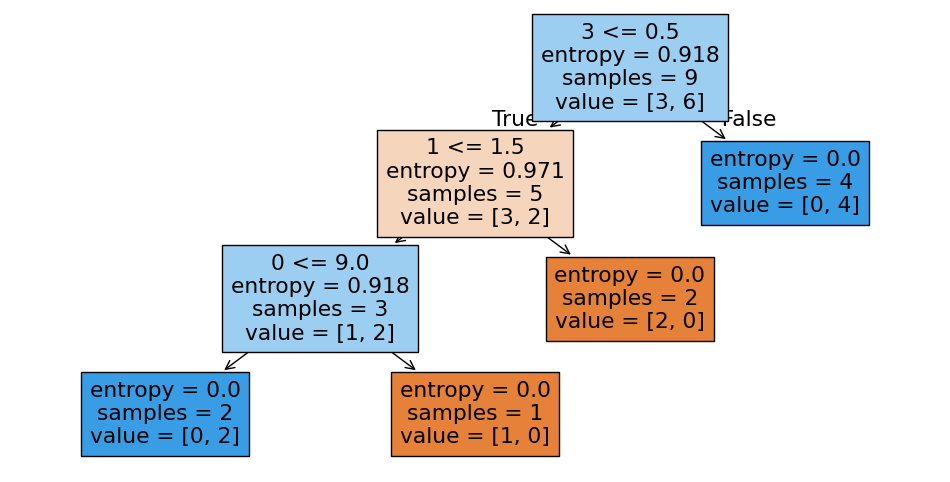

Predicted Class: 0


In [ ]:
#--------------------------------------
# 3.Decision tree based ID3 algorithm.
#--------------------------------------

import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import io
import ast # Import ast for literal_eval
from IPython.display import display

# Upload Dataset
uploaded = files.upload()
filename = next(iter(uploaded))
raw_data = uploaded[filename].decode('utf-8')

# Process the raw data to correctly parse the list-like format
data_rows = []
for line in raw_data.strip().split('\n'):
    # Clean the line: remove leading/trailing spaces, and the trailing comma if present.
    cleaned_line = line.strip().rstrip(',')
    try:
        # Use ast.literal_eval to safely parse the string representation of a list
        parsed_list = ast.literal_eval(cleaned_line)
        data_rows.append(parsed_list)
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing line: {cleaned_line}. Skipping. Error: {e}")
        continue

# Create DataFrame from the list of lists
df = pd.DataFrame(data_rows)

print("Dataset:")
display(df.head())

# Encode Categorical Columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train ID3 Model
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Decision Tree
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

# Predict a New Sample
sample = X.iloc[0].values.reshape(1, -1)   # Example sample
prediction = model.predict(sample)

print("Predicted Class:", prediction[0])

In [ ]:
#----------------------------------
# 7.Logistic Regression Algorithm
#----------------------------------

import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Upload Dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

print("Dataset:")
display(df.head())

# Encode Categorical Columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Normalize Data
X = StandardScaler().fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Predict First Test Sample
print("Predicted Class:", model.predict([X_test[0]])[0])
print("Actual Class:", y_test.iloc[0] if hasattr(y_test, "iloc") else y_test[0])

Saving Customer_Transactions.csv to Customer_Transactions.csv
Dataset:


,customer_id,age,gender,country,annual_income,spending_score,num_purchases,avg_purchase_value,membership_years,website_visits_per_month,cart_abandon_rate,churned,feedback_text,last_purchase_date
0,1,37,Male,Germany,85886,14,18,41.20,6,20,0.95,0,Very satisfied with my purchase.,2025-06-22
1,2,40,Male,India,41041,4,10,31.73,4,29,0.21,0,Good quality and value for money.,2025-10-17
2,3,69,Female,Australia,143869,59,39,65.96,12,26,0.08,0,Excellent customer service.,2025-07-01
3,4,30,Male,UK,87261,45,34,51.87,12,7,0.61,0,Good quality and value for money.,2025-08-17
4,5,69,Female,UK,110678,40,38,59.64,13,16,0.49,0,Excellent customer service.,2025-06-21


Accuracy: 0.65 %
Predicted Class: 497
Actual Class: 544


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Upload Dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

print("Dataset:")
display(df.head())

# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

# Predict First Test Sample
# Convert the single sample to a NumPy array to avoid the UserWarning
print("Predicted Value:", round(model.predict(X_test.iloc[0].values.reshape(1, -1))[0], 2))
print("Actual Value:", y_test.iloc[0])

Saving test.csv to test.csv
Dataset:


,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


Mean Squared Error: 9.26
R2 Score: 0.99
Predicted Value: 90.85
Actual Value: 92.88772282


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#------------------------------------------------
# 10.Expectation-Maximization (EM) Algorithm
#------------------------------------------------

import pandas as pd
from google.colab import files
from sklearn.mixture import GaussianMixture
import io # Import for handling in-memory files

# Upload Dataset
uploaded = files.upload()

# Get filename and content as bytes
filename = next(iter(uploaded))
file_content = uploaded[filename]

# Use pd.read_excel for .xlsx files, otherwise try pd.read_csv
if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

print("Dataset:")
display(df.head())

# Features (Last column is ignored if it is a target)
X = df.iloc[:, :-1]

# EM Algorithm using Gaussian Mixture Model
model = GaussianMixture(n_components=2, random_state=42)
model.fit(X)

# Predict Clusters
clusters = model.predict(X)

# Display Results
df["Cluster"] = clusters
print("\nClustered Data:")
display(df)

print("Cluster Labels:")
print(clusters)

Saving customer_data.csv.xlsx to customer_data.csv (1).xlsx
Dataset:


,Age,Income,SpendingScore
0,22,25000,35
1,25,30000,40
2,28,35000,45
3,30,40000,50
4,32,45000,55



Clustered Data:


,Age,Income,SpendingScore,Cluster
0,22,25000,35,1
1,25,30000,40,1
2,28,35000,45,1
3,30,40000,50,1
4,32,45000,55,1
5,35,50000,60,1
6,38,55000,62,0
7,40,60000,65,0
8,42,65000,68,0
9,45,70000,70,0


Cluster Labels:
[1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0]


In [ ]:
#--------------------------------------
# 5.K-Nearest Neighbours (K-NN)
#--------------------------------------
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import io

# Upload Dataset
uploaded = files.upload()

# Get filename and content as bytes
filename = next(iter(uploaded))
file_content = uploaded[filename]

# Use pd.read_excel for .xlsx files, otherwise try pd.read_csv
if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

print(df.head())

# Encode Categorical Data
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])

# Features and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Normalize Features
X = StandardScaler().fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train K-NN Model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# Predict First Test Sample
print("Predicted Class:", model.predict([X_test[0]])[0])
print("Actual Class:", y_test.iloc[0])

Saving student_knn.csv.xlsx to student_knn.csv (1).xlsx
   StudyHours  Attendance  AssignmentMarks  PreviousMarks  Result
0           2          60               50             45       0
1           3          65               55             50       0
2           4          70               60             55       0
3           5          75               65             60       1
4           6          80               70             65       1
Accuracy: 66.67 %
Predicted Class: 0
Actual Class: 0


In [ ]:
#--------------------------------------------------------------------------
# 4.Artificial Neural Network by implementing the Backpropagation algorithm
#--------------------------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from google.colab import files
import io # Import for handling in-memory files

# Load dataset
# Upload Dataset
uploaded = files.upload()

# Read the uploaded file based on its extension
filename = list(uploaded.keys())[0]
file_content = uploaded[filename]

if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

# Separate input and output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Convert categorical output into numbers
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale input data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Artificial Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000, # Increased max_iter to improve convergence
    random_state=42
)

# Train using Backpropagation
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Saving iris.csv.xlsx to iris.csv (2).xlsx
Accuracy: 0.5

Confusion Matrix:
[[0 1]
 [0 1]]


In [ ]:
#------------------------------------------
# 2.Candidate-Elimination algorithm
#------------------------------------------

import pandas as pd
from google.colab import files
import io

# Upload CSV file
uploaded = files.upload()

# Read the uploaded file based on its extension
filename = list(uploaded.keys())[0]
file_content = uploaded[filename]

if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

# Attributes and target
attributes = df.columns[:-1]
target = df.columns[-1]

# Initialize Specific and General hypotheses
S = ['∅'] * len(attributes)
G = [['?'] * len(attributes)]

# Candidate Elimination
for _, row in df.iterrows():
    x = list(row[attributes])
    label = row[target]

    if str(label).lower() in ['yes', 'true', '1', 'positive']:
        # Generalize S
        for i in range(len(S)):
            if S[i] == '∅':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

        # Remove inconsistent hypotheses from G
        G = [g for g in G if all(g[i] == '?' or g[i] == x[i] for i in range(len(x)))]

    else:
        # Specialize G
        new_G = []

        for g in G:
            for i in range(len(x)):
                if g[i] == '?':
                    if S[i] != '?' and S[i] != '∅':
                        new_g = g.copy()
                        new_g[i] = S[i]
                        new_G.append(new_g)

        G = new_G

print("Specific Hypothesis (S):")
print(S)

print("\nGeneral Hypothesis (G):")
for g in G:
    print(g)


Saving training_data.csv.xlsx to training_data.csv (1).xlsx
Specific Hypothesis (S):
['Sunny', 'Warm', '?', '?']

General Hypothesis (G):
['Sunny', '?', '?', '?']
['?', 'Warm', '?', '?']


Saving weather_dataset.xlsx to weather_dataset.xlsx
Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]


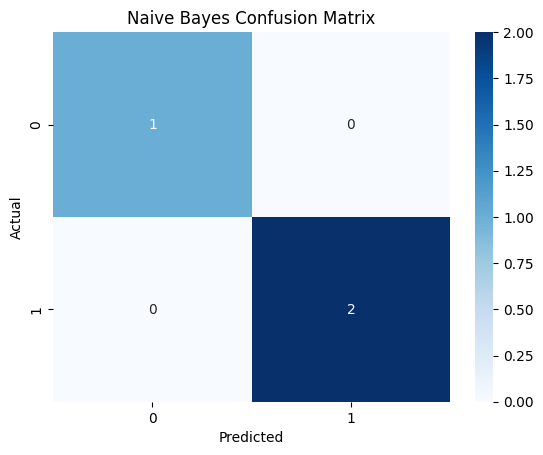

In [ ]:
#------------------------------
# 6.Naïve Bayes algorithm
#------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
# Upload Dataset
uploaded = files.upload()

# Read the uploaded file based on its extension
filename = list(uploaded.keys())[0]
file_content = uploaded[filename]

if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

# Convert categorical data to numbers
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Separate input and output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Saving linear_polynomial_regression_dataset.xlsx to linear_polynomial_regression_dataset.xlsx
Linear Regression
MSE: 6.964365338882265
R2 Score: 0.9772592152199763

Polynomial Regression
MSE: 0.14040588577827598
R2 Score: 0.9995415318015404


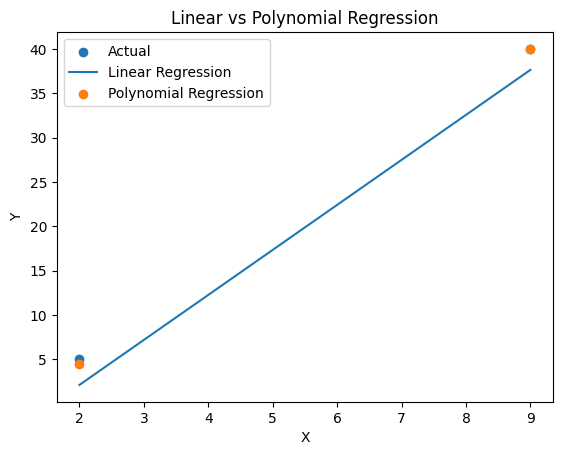

In [ ]:
#-----------------------------------------
# 9.Linear and Polynomial Regression
#-----------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
# Upload Dataset
uploaded = files.upload()

# Read the uploaded file based on its extension
filename = list(uploaded.keys())[0]
file_content = uploaded[filename]

if filename.endswith('.xlsx'):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
else:
    raise ValueError("Unsupported file format. Please upload a .csv or .xlsx file.")

# Change these according to your dataset
X = df[['X']]
y = df['Y']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

polynomial = LinearRegression()
polynomial.fit(X_train_poly, y_train)
poly_pred = polynomial.predict(X_test_poly)

# Results
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, linear_pred))
print("R2 Score:", r2_score(y_test, linear_pred))

print("\nPolynomial Regression")
print("MSE:", mean_squared_error(y_test, poly_pred))
print("R2 Score:", r2_score(y_test, poly_pred))

# Graph
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, linear_pred, label="Linear Regression")
plt.scatter(X_test, poly_pred, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Features and target
X = df.select_dtypes(include='number').iloc[:, :-1]
y = df.iloc[:, -1]

# Convert target to numbers if needed
y = y.astype('category').cat.codes

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Saving test.csv.zip to test.csv (1).zip
Accuracy: 0.0


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Encode Categorical Columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# KNN model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Saving adult.csv.zip to adult.csv (3).zip
Accuracy: 0.7635377213634967


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Numerical columns
data = df.select_dtypes(include='number')

# Last column as target (Price)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Saving car_prediction_data.csv to car_prediction_data.csv
R2 Score: -0.39465871687357734
Mean Squared Error: 0.02248845015114611


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Select numerical data
data = df.select_dtypes(include='number')

# Last column = House Price
# Ensure there are enough columns for features (X) and target (y)
if data.shape[1] < 2:
    print("Error: The dataset must contain at least two numerical columns (one for features, one for target).")
    print("Current numerical columns:", data.columns.tolist())
else:
    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    print("R2 Score:", r2_score(y_test, y_pred))
    print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


Saving data.csv to data.csv
R2 Score: 0.2163150251754573
Mean Squared Error: 755134.6921245499


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Check if DataFrame is empty after dropping NaNs
if df.empty:
    print("Error: The DataFrame is empty after removing missing values. Please check your dataset or preprocessing steps.")
else:
    # Identify the target column, typically 'Attrition_Flag' for BankChurners dataset
    target_column = 'Attrition_Flag'

    if target_column not in df.columns:
        print(f"Error: Target column '{target_column}' not found. Available columns: {df.columns.tolist()}")
    else:
        # Separate features (X) and target (y)
        y = df[target_column]

        # Drop the target column, CLIENTNUM (ID column), and the two 'Naive_Bayes_Classifier' probability columns from features (X)
        # These probability columns are typically present in the BankChurners dataset as pre-computed scores,
        # and should not be used as features for training a new classifier on the same target.
        columns_to_drop = ['CLIENTNUM', target_column]
        # Check for the presence of the problematic Naive Bayes probability columns by their expected names
        for col_name in [
            'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
            'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
        ]:
            if col_name in df.columns and col_name not in columns_to_drop:
                columns_to_drop.append(col_name)

        X = df.drop(columns=columns_to_drop)

        # Encode categorical columns in X
        le = LabelEncoder()
        for col in X.columns:
            if X[col].dtype == 'object':
                X[col] = le.fit_transform(X[col])

        # Encode target variable y if it's categorical
        if y.dtype == 'object':
            y = le.fit_transform(y)
        elif y.dtype not in ['int64', 'float64']: # This case should ideally not happen if target is well-defined
            print(f"Warning: Target variable 'y' has an unexpected dtype: {y.dtype}. Expected 'object' or numerical.")

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Naive Bayes model
        model = GaussianNB()
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        print("Accuracy:", accuracy_score(y_test, y_pred))


Saving BankChurners.csv.zip to BankChurners.csv (1).zip
Accuracy: 0.8830207305034551


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded))).dropna()

# Convert categorical columns to numbers
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB()
}

# Compare accuracy
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, ":", accuracy_score(y_test, pred))

Saving Titanic-Dataset.csv to Titanic-Dataset.csv
Logistic Regression : 0.5945945945945946
KNN : 0.5135135135135135
Decision Tree : 0.7027027027027027
Naive Bayes : 0.5945945945945946


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))

# Remove missing values
df = df.dropna()

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Saving Mobile-Price-Prediction-cleaned_data.csv to Mobile-Price-Prediction-cleaned_data.csv
Accuracy: 0.5370370370370371


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded))).dropna()

# Remove ID column if present
df = df.select_dtypes(include=['number']).join(
    df.select_dtypes(exclude=['number']).iloc[:, -1]
)

# Features and target
X = df.iloc[:, :-1]
y = LabelEncoder().fit_transform(df.iloc[:, -1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Perceptron
model = Perceptron()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Saving IRIS.csv to IRIS.csv
Accuracy: 0.8333333333333334


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)), sep=';').dropna() # Added sep=';'

# Convert text columns to numbers
for col in df.select_dtypes(include='object'):
    df[col] = LabelEncoder().fit_transform(df[col])

# Features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Saving bank-additional-full.csv.zip to bank-additional-full.csv (1).zip
Accuracy: 0.8505705268268997


In [ ]:
import pandas as pd
from google.colab import files
from sklearn.linear_model import LinearRegression

# Upload Kaggle dataset
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded))).dropna()

# Select numerical columns
data = df.select_dtypes(include='number')

# First column = time, last column = sales
X = data.iloc[:, 0:1]
y = data.iloc[:, -1]

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict future sales
future = [[X.iloc[-1, 0] + 1]]
prediction = model.predict(future)

print("Predicted Future Sales:", prediction[0])

Saving features.csv to features.csv
Predicted Future Sales: 8.11774973726907


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
